In [1]:
import numpy as np
import matplotlib.pyplot as plt

data = np.load('../../../remote_inbox/bams_f/bams_fig_data.npz')

In [2]:
pab, x_train, y_train = data['pab'], data['xtrain'],data['ytrain']

def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx, array[idx]

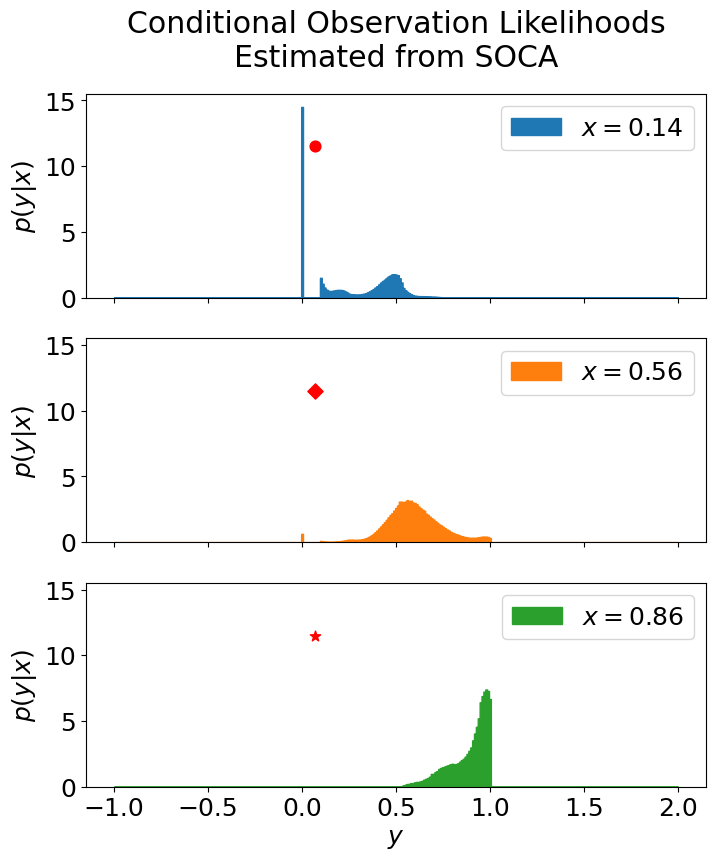

In [5]:
plt.rcParams.update({'font.size': 18})

n_sample = 20000
unif_domain = np.linspace(-1,2,n_sample)
ys = np.sort(y_train[0, :])
ind2 = np.argsort(y_train[0, :])
diff = np.diff(ys)

cmap = plt.get_cmap('tab10')

htp = []

# for fnum in range(2):
fig, axs = plt.subplots(3, 1, sharex=True,figsize=(8,9))
markers=['o','D','*']
for ind, j in enumerate([0.14, 0.56, 0.86]):

      ax = axs[ind]
      dum = np.abs(j - x_train[0, :])
      ind1 = np.argsort(dum)[0]

      h = pab[ind2, ind1]

      # Normalize for plotting
      normalization = np.sum((h[:-1] + h[1:]) * diff / 2)
      h_norm = h / normalization
      htp.append(h_norm)

      h_plot = np.zeros_like(unif_domain)
      for k, gp in enumerate(unif_domain):
          idx, nearest = find_nearest(ys, gp)
          if np.abs(nearest - gp) > 0.005:
              h_plot[k] = 0
          else:
              h_plot[k] = h_norm[idx]
          
    # ORIGINAL
      #ax.plot(ys, h_norm, linewidth=4, color=cmap(ind),label=f'$x = {j}$')
    # SECONDARY DOMAIN
      ax.fill_between(unif_domain, h_plot, 0, color=cmap(ind), label=f'$x = {j}$')

      bound = max(np.abs(np.min(x_train)), np.abs(np.max(x_train)))
      #ax.set_xlim([0, 1])
      ax.legend()
      ax.set_ylabel('$p(y|x)$')
      ax.scatter(0.07, 11.5, marker=markers[ind], c='red', s=60)
axs[0].set_ylim([0, np.max(htp) + 1])
axs[1].set_ylim([0, np.max(htp) + 1])
axs[2].set_ylim([0, np.max(htp) + 1])

axs[0].set_title(f'Conditional Observation Likelihoods\nEstimated from SOCA', pad=20)

axs[2].set_xlabel('$y$')

      # fig.savefig(figpath + f'test-knnf{knnf}-bw{bw}-klb{klb}_slide{fnum}.png')

      # fig.savefig(figpath + new_dir_path + f'knnf{knnf}_bw{bw}_klb{klb}_slide{fnum:02d}.png')
plt.savefig('bams_nles_fixed_dom.png')
plt.show()
plt.close(fig)


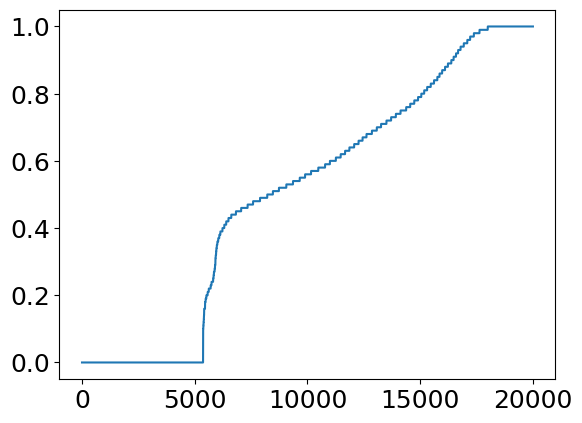

In [135]:
plt.plot(ys)

In [155]:
ys[5369:5418]

array([0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.11,
       0.11, 0.11, 0.11, 0.11, 0.11, 0.11, 0.11, 0.11, 0.11, 0.12, 0.12,
       0.12, 0.12, 0.12, 0.12, 0.12, 0.12, 0.12, 0.12, 0.13, 0.13, 0.13,
       0.13, 0.13, 0.13, 0.13, 0.14, 0.14, 0.14, 0.14, 0.14, 0.14, 0.14,
       0.14, 0.15, 0.15, 0.15, 0.15], dtype=float32)